# 18B. 원곡·생성기 수를 맞춘 분류

12개 생성기가 모두 있는 원곡에서 `original_audio × generator`마다 한 곡만 남겼다. 각 곡의 Segment 특징을 평균해 266차원 입력 하나로 만든다. 이 엄격한 균형 조건에서 생성기 분류가 유지되는지 확인한다.

## 1. 라이브러리 / 경로 / 데이터 로드

In [1]:
from pathlib import Path
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

FEATURE_PATH = PROJECT_ROOT / "data/processed/features/handcrafted_features_10s.csv"

SEGMENT_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"

PREVIOUS_METRICS_PATH = (
    PROJECT_ROOT
    / "results/generator_attribution/handcrafted/generator_attribution_metrics.csv"
)

RESULT_DIR = PROJECT_ROOT / "results/generator_attribution/balanced_controlled"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints/generator_attribution"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

features = pd.read_csv(FEATURE_PATH)
segments = pd.read_csv(SEGMENT_PATH).reset_index(drop=True)

print("Feature rows :", len(features))
print("Segment rows :", len(segments))
print("Previous metrics exists:", PREVIOUS_METRICS_PATH.exists())

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(features) == 10077
assert len(segments) == 10077

print("Input QC PASS: True")

Feature rows : 10077
Segment rows : 10077
Previous metrics exists: True
Input QC PASS: True


## 2. 266개 handcrafted feature 재확인

In [2]:
segment_meta_cols = set(segments.columns)

extra_meta_cols = {
    "Unnamed: 0",
    "index",
    "cache_index",
    "extraction_success",
    "success",
    "error",
}

feature_cols = [
    c
    for c in features.columns
    if c != "segment_id"
    and c not in segment_meta_cols
    and c not in extra_meta_cols
    and not str(c).startswith("Unnamed:")
    and pd.api.types.is_numeric_dtype(features[c])
]

print("Detected feature columns:", len(feature_cols))

if len(feature_cols) != 266:
    raise ValueError(f"Expected 266 handcrafted features, got {len(feature_cols)}")

meta = segments[
    [
        "segment_id",
        "track_sample_id",
        "original_audio",
        "label",
        "label_id",
        "generator",
        "genre",
        "split",
    ]
].copy()

data = meta.merge(
    features[["segment_id"] + feature_cols],
    on="segment_id",
    how="inner",
    validate="one_to_one",
)

fake = data[data["label"] == "FAKE"].copy()

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(fake) == 9189
assert fake["generator"].nunique() == 12
assert not fake[feature_cols].isna().any().any()
assert not np.isinf(fake[feature_cols].to_numpy()).any()

print("FAKE segments:", len(fake))
print("Generators   :", fake["generator"].nunique())
print("Handcrafted Feature QC PASS: True")

Detected feature columns: 266
FAKE segments: 9189
Generators   : 12
Handcrafted Feature QC PASS: True


## 3. Strict balanced source-generator track 선택

1. Track metadata에서 `original_audio`별 generator 수를 계산
2. 12개 generator가 모두 존재하는 source만 유지
3. 각 `original_audio × generator`에서 `track_sample_id`를 정렬
4. 가장 첫 track 하나만 deterministic하게 선택

In [3]:
track_meta = (
    fake[
        [
            "track_sample_id",
            "original_audio",
            "generator",
            "genre",
            "split",
        ]
    ]
    .drop_duplicates("track_sample_id")
    .copy()
)

source_gen_count = track_meta.groupby("original_audio")["generator"].nunique()

common_12_sources = set(source_gen_count[source_gen_count == 12].index)

print("Sources with all 12 generators:", len(common_12_sources))

strict_pool = track_meta[track_meta["original_audio"].isin(common_12_sources)].copy()

selected_tracks = (
    strict_pool.sort_values(["original_audio", "generator", "track_sample_id"])
    .groupby(["original_audio", "generator"], as_index=False)
    .first()
)

print("Selected tracks:", len(selected_tracks))

expected_tracks = len(common_12_sources) * 12

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(selected_tracks) == expected_tracks
assert selected_tracks.groupby("original_audio")["generator"].nunique().eq(12).all()

# source-generator당 정확히 1 track
pair_counts = selected_tracks.groupby(["original_audio", "generator"]).size()

assert pair_counts.eq(1).all()

print("\nSelected track distribution")
display(
    pd.crosstab(
        selected_tracks["generator"],
        selected_tracks["split"],
    )
)

print("\nUnique source groups by split")
source_split_counts = selected_tracks.groupby("split")["original_audio"].nunique()

display(source_split_counts.to_frame("unique_original_audio"))

print("\nExpected Train/Val/Test source counts: 83 / 17 / 19")
print(
    "Actual:",
    int(source_split_counts.get("train", 0)),
    int(source_split_counts.get("val", 0)),
    int(source_split_counts.get("test", 0)),
)

# generator별 track 수가 split 내에서 완전히 동일한지 확인
dist = pd.crosstab(
    selected_tracks["generator"],
    selected_tracks["split"],
)

for split in ["train", "val", "test"]:
    assert dist[split].nunique() == 1

assert int(dist["train"].iloc[0]) == 83
assert int(dist["val"].iloc[0]) == 17
assert int(dist["test"].iloc[0]) == 19

print("Strict Balanced Track Selection QC PASS: True")

Sources with all 12 generators: 119
Selected tracks: 1428

Selected track distribution


split,test,train,val
generator,,,
acestep,19,83,17
audioldm,19,83,17
brev,19,83,17
diffrhythm,19,83,17
elevenlabs,19,83,17
mubert,19,83,17
musicgen,19,83,17
producer,19,83,17
songgen,19,83,17



Unique source groups by split


,unique_original_audio
split,
test,19
train,83
val,17



Expected Train/Val/Test source counts: 83 / 17 / 19
Actual: 83 17 19
Strict Balanced Track Selection QC PASS: True


## 4. Track-level 266-D feature 생성

선택된 각 track에 속한 segment의 266개 feature를 평균한다.

이렇게 하면:
- 1 segment track
- 2 segment track
- 3 segment track

모두 **track당 1개의 266-D vector**가 되어 segment 개수 차이도 통제된다.

In [4]:
selected_ids = set(selected_tracks["track_sample_id"])

selected_segments = fake[fake["track_sample_id"].isin(selected_ids)].copy()

track_features = selected_segments.groupby("track_sample_id", as_index=False).agg(
    {
        **{
            "original_audio": "first",
            "generator": "first",
            "genre": "first",
            "split": "first",
        },
        **{c: "mean" for c in feature_cols},
    }
)

segment_counts = (
    # 같은 곡의 10초 구간을 묶어 곡 단위 결과를 만든다.
    selected_segments.groupby("track_sample_id").size().rename("segment_count")
)

track_features = track_features.merge(
    segment_counts,
    on="track_sample_id",
    how="left",
    validate="one_to_one",
)

print("Track feature rows:", len(track_features))
print("Track feature dims:", len(feature_cols))

print("\nSegment count distribution per selected track")
display(track_features["segment_count"].value_counts().sort_index().to_frame("tracks"))

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(track_features) == expected_tracks
assert len(feature_cols) == 266
assert not track_features[feature_cols].isna().any().any()
assert not np.isinf(track_features[feature_cols].to_numpy()).any()

print("Track Feature Aggregation QC PASS: True")

Track feature rows: 1428
Track feature dims: 266

Segment count distribution per selected track


,tracks
segment_count,
1,2
2,120
3,1306


Track Feature Aggregation QC PASS: True


## 5. 평가 함수

In [5]:
# 평가 함수
def top_k_accuracy(
    y_true,
    score_matrix,
    k=3,
):
    topk = np.argsort(
        score_matrix,
        axis=1,
    )[:, -k:]

    return float(
        np.mean(
            [
                int(y) in row
                for y, row in zip(
                    y_true,
                    topk,
                )
            ]
        )
    )


def macro_ovr_auc(
    y_true,
    score_matrix,
    n_classes,
):
    aucs = []

    for cls in range(n_classes):
        y_bin = (np.asarray(y_true) == cls).astype(int)

        if y_bin.min() == y_bin.max():
            continue

        aucs.append(
            roc_auc_score(
                y_bin,
                score_matrix[:, cls],
            )
        )

    return float(np.mean(aucs))


def evaluate_multiclass(
    y_true,
    scores,
    n_classes,
):
    pred = np.argmax(
        scores,
        axis=1,
    )

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                pred,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                pred,
            )
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                pred,
                average="macro",
                zero_division=0,
            )
        ),
        "top3_accuracy": float(
            top_k_accuracy(
                y_true,
                scores,
                3,
            )
        ),
        "macro_ovr_auc": float(
            macro_ovr_auc(
                y_true,
                scores,
                n_classes,
            )
        ),
    }

## 6. Strict Balanced 12-way RBF-SVM

In [6]:
generator_order = sorted(track_features["generator"].unique())

encoder = LabelEncoder()
# 분류 경계는 Train에만 맞추고 Validation/Test는 선택·평가에 남겨둔다.
encoder.fit(generator_order)

# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
train = track_features[track_features["split"] == "train"].reset_index(drop=True)

val = track_features[track_features["split"] == "val"].reset_index(drop=True)

test = track_features[track_features["split"] == "test"].reset_index(drop=True)

print(
    "Train / Val / Test tracks:",
    len(train),
    len(val),
    len(test),
)

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(train) == 996
assert len(val) == 204
assert len(test) == 228

X_train = train[feature_cols].to_numpy(dtype=np.float32)
X_val = val[feature_cols].to_numpy(dtype=np.float32)
X_test = test[feature_cols].to_numpy(dtype=np.float32)

# Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
y_train = encoder.transform(train["generator"])
y_val = encoder.transform(val["generator"])
# Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
y_test = encoder.transform(test["generator"])

# 특징마다 범위가 달라 표준화한다. 평균·표준편차는 Train에서만 구한다.
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_val_z = scaler.transform(X_val)
X_test_z = scaler.transform(X_test)

clf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    # 클래스별 표본 수가 달라 손실에 기여하는 비중을 조정한다.
    class_weight=None,  # 완전 균형이므로 별도 weighting 불필요
    decision_function_shape="ovr",
    probability=False,
    cache_size=3000,
    random_state=RANDOM_STATE,
)

print("Training strict balanced RBF-SVM...")
start = time.time()

clf.fit(
    X_train_z,
    y_train,
)

print(
    "Training elapsed:",
    round(
        (time.time() - start) / 60,
        3,
    ),
    "min",
)

# SVM의 decision score는 확률이 아닌 분류 경계까지의 margin이다.
val_scores = clf.decision_function(X_val_z)

test_scores = clf.decision_function(X_test_z)

val_metrics = evaluate_multiclass(
    y_val,
    val_scores,
    12,
)

test_metrics = evaluate_multiclass(
    y_test,
    test_scores,
    12,
)

strict_metrics = pd.DataFrame(
    [
        {
            "experiment": "strict_balanced_controlled",
            "split": "val",
            **val_metrics,
        },
        {
            "experiment": "strict_balanced_controlled",
            "split": "test",
            **test_metrics,
        },
    ]
)

display(strict_metrics.round(4))

print("Random Top-1 chance:", round(1 / 12, 4))

Train / Val / Test tracks: 996 204 228
Training strict balanced RBF-SVM...
Training elapsed: 0.001 min


,experiment,split,accuracy,balanced_accuracy,macro_f1,top3_accuracy,macro_ovr_auc
0,strict_balanced_controlled,val,0.7500,0.7500,0.7486,0.9608,0.9614
1,strict_balanced_controlled,test,0.7544,0.7544,0.7447,0.9386,0.9534


Random Top-1 chance: 0.0833


## 7. Generator별 Strict Balanced Test 성능 / Confusion Matrix

,generator,precision,recall,f1-score,support
6,musicgen,1.0000,1.0000,1.0000,19.0
1,audioldm,0.9000,0.9474,0.9231,19.0
3,diffrhythm,0.9000,0.9474,0.9231,19.0
8,songgen,0.9000,0.9474,0.9231,19.0
0,acestep,0.8889,0.8421,0.8649,19.0
9,stableaudio,0.8750,0.7368,0.8000,19.0
4,elevenlabs,0.6957,0.8421,0.7619,19.0
5,mubert,0.7778,0.7368,0.7568,19.0
7,producer,0.5600,0.7368,0.6364,19.0
10,suno,0.5200,0.6842,0.5909,19.0


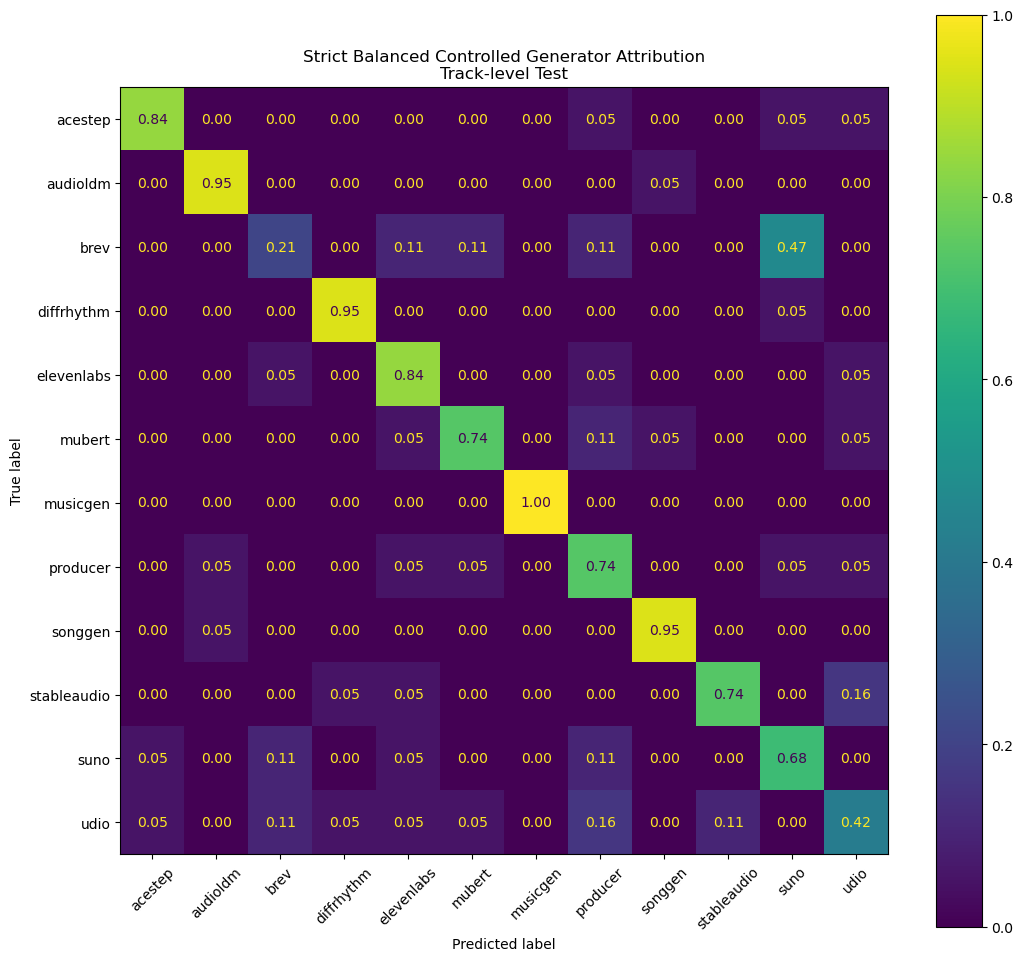

Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/generator_attribution/balanced_controlled/strict_balanced_track_confusion_matrix.png


In [7]:
pred_int = np.argmax(
    test_scores,
    axis=1,
)

pred = encoder.inverse_transform(pred_int)

report = classification_report(
    test["generator"],
    pred,
    labels=encoder.classes_,
    output_dict=True,
    zero_division=0,
)

per_generator = (
    pd.DataFrame(report)
    .T.loc[
        encoder.classes_,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
    .reset_index()
    .rename(columns={"index": "generator"})
)

display(
    per_generator.sort_values(
        "f1-score",
        ascending=False,
    ).round(4)
)

cm = confusion_matrix(
    test["generator"],
    pred,
    labels=encoder.classes_,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(11, 10))

ConfusionMatrixDisplay(
    cm,
    display_labels=encoder.classes_,
).plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f",
)

ax.set_title("Strict Balanced Controlled Generator Attribution\n" "Track-level Test")

fig.tight_layout()

fig_path = RESULT_DIR / "strict_balanced_track_confusion_matrix.png"

fig.savefig(
    fig_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig_path)

## 8. 기존 Full / Controlled 결과와 비교

In [8]:
if not PREVIOUS_METRICS_PATH.exists():
    raise FileNotFoundError("18번 generator_attribution_metrics.csv가 없습니다.")

previous = pd.read_csv(PREVIOUS_METRICS_PATH)

previous_track_test = previous[
    # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
    (previous["level"] == "track") & (previous["split"] == "test")
][
    [
        "experiment",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "top3_accuracy",
        "macro_ovr_auc",
    ]
].copy()

strict_test = strict_metrics[strict_metrics["split"] == "test"][
    [
        "experiment",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "top3_accuracy",
        "macro_ovr_auc",
    ]
].copy()

comparison = pd.concat(
    [
        previous_track_test,
        strict_test,
    ],
    ignore_index=True,
)

display(comparison.round(4))

print("\nChance Top-1:", round(1 / 12, 4))

,experiment,accuracy,balanced_accuracy,macro_f1,top3_accuracy,macro_ovr_auc
0,full,0.8846,0.8812,0.8840,0.9798,0.9765
1,controlled_12,0.7720,0.8004,0.8064,0.9642,0.9641
2,strict_balanced_controlled,0.7544,0.7544,0.7447,0.9386,0.9534



Chance Top-1: 0.0833


## 9. 균형 조건의 변화량

Strict balanced는 원곡 범위와 생성기별 곡 수를 더 엄격하게 맞춘다. 이 조건에서 Macro-F1이 어떻게 달라졌는지 기존 controlled_12 결과와 비교한다.

In [9]:
# 두 표본 구성에서 같은 지표가 얼마나 달라졌는지 계산한다.
controlled_row = comparison[comparison["experiment"] == "controlled_12"].iloc[0]

strict_row = comparison[comparison["experiment"] == "strict_balanced_controlled"].iloc[
    0
]

delta = pd.DataFrame(
    [
        {
            "metric": "accuracy",
            "controlled_12": controlled_row["accuracy"],
            "strict_balanced": strict_row["accuracy"],
            "change": (strict_row["accuracy"] - controlled_row["accuracy"]),
        },
        {
            "metric": "balanced_accuracy",
            "controlled_12": controlled_row["balanced_accuracy"],
            "strict_balanced": strict_row["balanced_accuracy"],
            "change": (
                strict_row["balanced_accuracy"] - controlled_row["balanced_accuracy"]
            ),
        },
        {
            "metric": "macro_f1",
            "controlled_12": controlled_row["macro_f1"],
            "strict_balanced": strict_row["macro_f1"],
            "change": (strict_row["macro_f1"] - controlled_row["macro_f1"]),
        },
        {
            "metric": "macro_ovr_auc",
            "controlled_12": controlled_row["macro_ovr_auc"],
            "strict_balanced": strict_row["macro_ovr_auc"],
            "change": (strict_row["macro_ovr_auc"] - controlled_row["macro_ovr_auc"]),
        },
    ]
)

display(delta.round(4))

,metric,controlled_12,strict_balanced,change
0,accuracy,0.7720,0.7544,-0.0176
1,balanced_accuracy,0.8004,0.7544,-0.0460
2,macro_f1,0.8064,0.7447,-0.0617
3,macro_ovr_auc,0.9641,0.9534,-0.0106


## 10. 저장 / 최종 QC

In [10]:
strict_metrics.to_csv(
    RESULT_DIR / "strict_balanced_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

per_generator.to_csv(
    RESULT_DIR / "strict_balanced_per_generator_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

comparison.to_csv(
    RESULT_DIR / "full_controlled_strict_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

selected_tracks.to_csv(
    RESULT_DIR / "strict_selected_tracks.csv",
    index=False,
    encoding="utf-8-sig",
)

artifact_path = CHECKPOINT_DIR / "generator_attribution_rbf_svm_strict_balanced.joblib"

joblib.dump(
    {
        "feature_cols": feature_cols,
        "classes": encoder.classes_.tolist(),
        "encoder": encoder,
        "scaler": scaler,
        "svm": clf,
        "selected_tracks": selected_tracks[
            [
                "track_sample_id",
                "original_audio",
                "generator",
                "split",
            ]
        ],
    },
    artifact_path,
)

qc = pd.DataFrame(
    {
        "check": [
            "feature_count",
            "common_sources",
            "selected_tracks",
            "train_tracks",
            "val_tracks",
            "test_tracks",
            "train_per_generator",
            "val_per_generator",
            "test_per_generator",
            "finite_test_macro_f1",
            "artifact_exists",
        ],
        "value": [
            len(feature_cols),
            len(common_12_sources),
            len(selected_tracks),
            len(train),
            len(val),
            len(test),
            int(train["generator"].value_counts().iloc[0]),
            int(val["generator"].value_counts().iloc[0]),
            int(test["generator"].value_counts().iloc[0]),
            np.isfinite(test_metrics["macro_f1"]),
            artifact_path.exists(),
        ],
    }
)

display(qc)

core_qc_pass = (
    len(feature_cols) == 266
    and len(common_12_sources) == 119
    and len(selected_tracks) == 1428
    and len(train) == 996
    and len(val) == 204
    and len(test) == 228
    and train["generator"].value_counts().nunique() == 1
    and val["generator"].value_counts().nunique() == 1
    and test["generator"].value_counts().nunique() == 1
    and np.isfinite(test_metrics["macro_f1"])
    and artifact_path.exists()
)

print("===== FINAL RESULT =====")
print(
    "Strict Balanced Generator Attribution Core QC PASS:",
    core_qc_pass,
)

,check,value
0,feature_count,266
1,common_sources,119
2,selected_tracks,1428
3,train_tracks,996
4,val_tracks,204
5,test_tracks,228
6,train_per_generator,83
7,val_per_generator,17
8,test_per_generator,19
9,finite_test_macro_f1,True


===== FINAL RESULT =====
Strict Balanced Generator Attribution Core QC PASS: True


## 원곡 균형 통제 결과

- 119개 source에서 `original_audio × generator`당 정확히 1개 track을 선택해 1,428개 완전 균형 표본을 구성했다.
- Train/Val/Test는 각각 996/204/228 tracks이며 모든 generator의 표본 수가 동일하다.
- Strict Test Accuracy와 Balanced Accuracy는 **0.7544**, Macro-F1은 **0.7447**이다.
- 12-way 균등 추측의 8.33%보다 높았다. 원곡 범위와 클래스 수를 맞춘 조건에서도 생성기 구분에 도움이 되는 차이가 남았다.
- 결과는 `results/generator_attribution/balanced_controlled/`에 저장했다.